In [1]:
# Load the autoreload extension
#%load_ext autoreload

# Set autoreload mode
#%autoreload 2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!git clone https://github.com/eceo-epfl/coralscapesScripts.git
%cd coralscapesScripts
!pip install -e .
!pip install segmentation-models-pytorch \
             transformers \
             peft \
             torchmetrics \
             monai \
             albumentations \
             tqdm \
             ftfy \
             regex \
             huggingface_hub \
             pyyaml \
             scikit-learn \
             matplotlib

Cloning into 'coralscapesScripts'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 64 (delta 18), reused 60 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 9.61 MiB | 30.17 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/coralscapesScripts
Obtaining file:///content/coralscapesScripts
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for coralscapes (pyproject.toml) ... done
  Created wheel for coralscapes: filename=coralscapes-0.1.0-0.editable-py3-none-any.whl size=2855 sha256=f550b747e2252ce7bf8d536e059b49c20b8439fab329f2265b6dbfd9acc8bcb0
  Stored in directory: /tmp/pip-ephem-wheel-cache-4f29m74o/wheels/a7/94/2e/a7f1718b5df49f04f164df1a2832c7cda6e05dc5fa04e4d17e
Successfully bu

# Setup

In [6]:
import torch

import albumentations as A

from torch.utils.data import DataLoader
from coralscapesScripts.datasets.dataset import Coralscapes
from coralscapesScripts.datasets.preprocess import get_preprocessor
from coralscapesScripts.datasets.utils import calculate_weights

from coralscapesScripts.segmentation.model import Benchmark_Run
from coralscapesScripts.segmentation.benchmarking import launch_benchmark

from coralscapesScripts.visualization import show_samples

from coralscapesScripts.logger import Logger, save_benchmark_run
from coralscapesScripts.io import setup_config, get_parser, update_config_with_args
import copy

In [7]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [8]:
device_count = torch.cuda.device_count()
for i in range(device_count):
    print(f"CUDA Device {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

CUDA Device 0: Tesla T4


device(type='cuda')

## Config

In [13]:
import os
os.chdir('/content/coralscapesScripts/nbs')
cfg = setup_config(config_path='../configs/deeplabv3+resnet50.yaml', config_base_path='../configs/base.yaml')

## Args

In [29]:
args_input = "--run-name=notebook_run_b4_e25 --batch-size=4 --batch-size-eval=4 --epochs=25"
args_input = args_input.split(" ")

parser = get_parser()
args = parser.parse_args(args_input)

cfg = update_config_with_args(cfg, args)
cfg_logger = copy.deepcopy(cfg)

# Data

In [15]:
transforms = {}
for split in cfg.augmentation:
    transforms[split] = A.Compose(
        [
            getattr(A, transform_name)(**transform_params) for transform_name, transform_params
                                                                 in cfg.augmentation[split].items()
        ]
    )

In [18]:
cfg.data.root = '/content/drive/MyDrive/Coralscapes_Data'

train_dataset = Coralscapes(root = cfg.data.root, split = 'train', transform = transforms["train"])
transform_target = cfg.training.eval.transform_target if cfg.training.eval is not None and cfg.training.eval.transform_target is not None else True
val_dataset = Coralscapes(root = cfg.data.root, split = 'val', transform = transforms["val"], transform_target=transform_target)
test_dataset = Coralscapes(root = cfg.data.root, split = 'test', transform = transforms["test"], transform_target=transform_target)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=cfg.data.batch_size, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.data.batch_size_eval, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=cfg.data.batch_size_eval, shuffle=False, num_workers=2)

In [20]:
print(len(train_loader), len(val_loader), len(test_loader))

758 83 196


In [21]:
weight = calculate_weights(train_dataset).to(device) if(cfg.data.weight) else None

## Visualizations

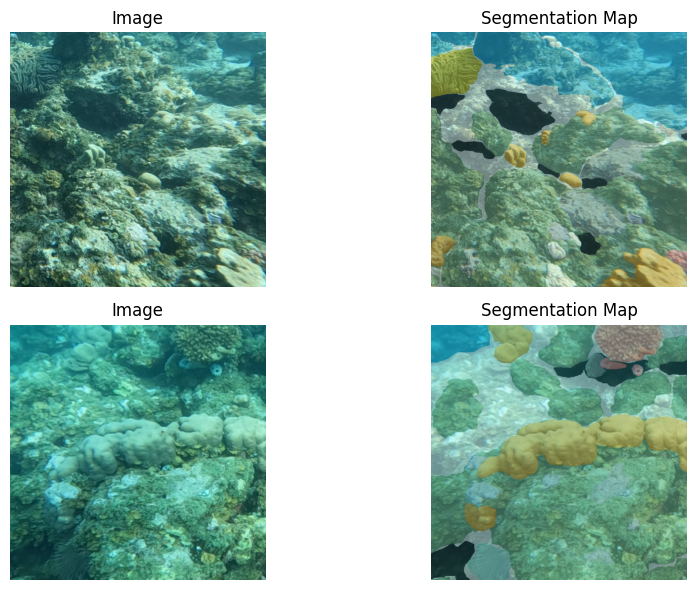

In [22]:
show_samples(train_dataset, n=2)

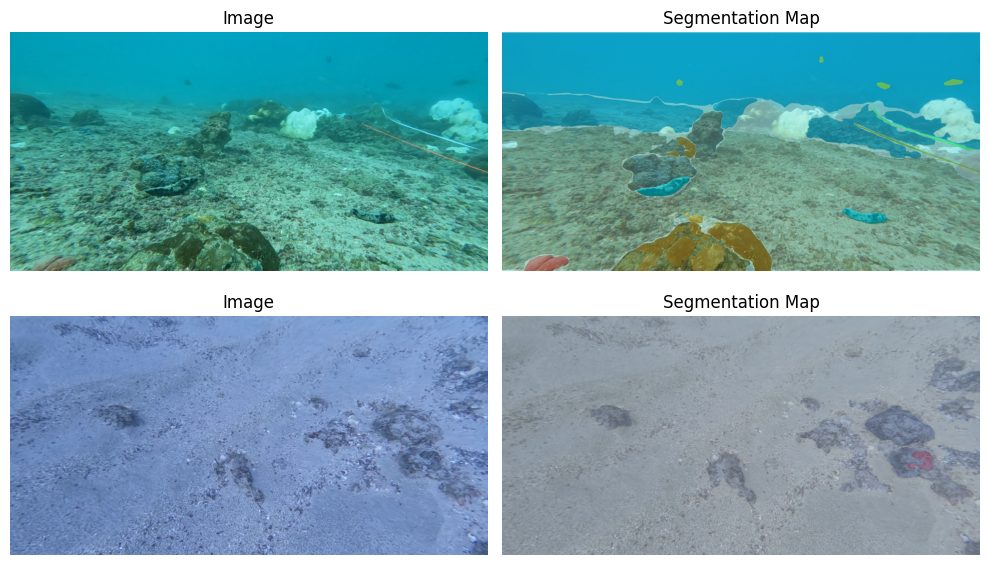

In [23]:
show_samples(val_dataset, n=2)

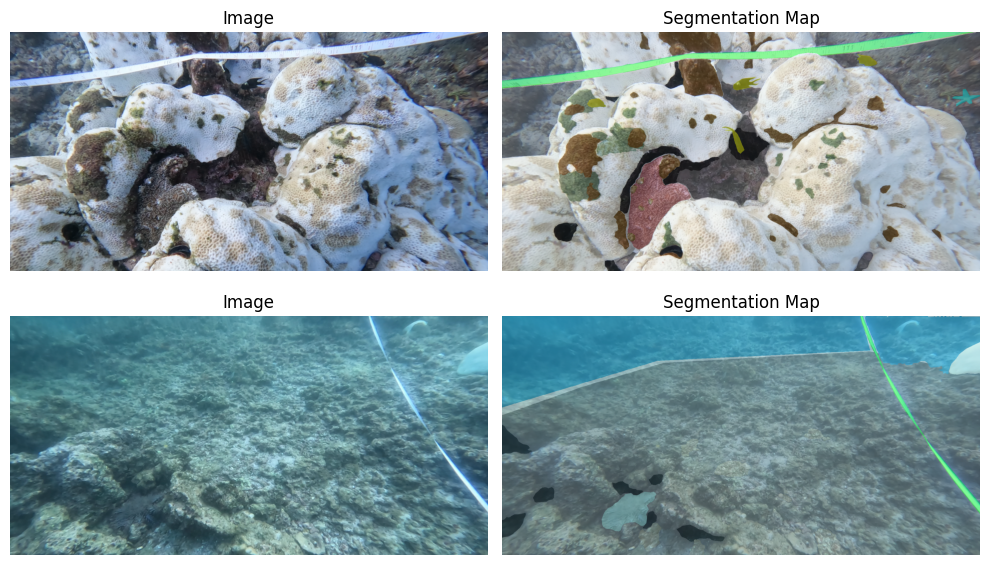

In [24]:
show_samples(test_dataset, n=2)

# Benchmarking

## Model

In [25]:
benchmark_run = Benchmark_Run(run_name = cfg.run_name, model_name = cfg.model.name,
                                    N_classes = train_dataset.N_classes, device= device,
                                    model_kwargs = cfg.model.kwargs,
                                    model_checkpoint = cfg.model.checkpoint,
                                    lora_kwargs = cfg.lora,
                                    training_hyperparameters = cfg.training)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

## Logger

In [26]:
logger = Logger(
    project = cfg.logger.wandb_project,
    benchmark_run = benchmark_run,
    log_epochs = cfg.logger.log_epochs,
    config = cfg_logger,
    checkpoint_dir = "./tmp"
)
# logger = None

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: andrea-allegrone (andrea-allegrone-university-of-genoa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Run

In [27]:
benchmark_run.print_trainable_parameters()

trainable params: 26687608 || all params: 26687608 || trainable%: 100.00


In [30]:
benchmark_metrics = launch_benchmark(train_loader, val_loader, test_loader, benchmark_run, logger = logger)
save_benchmark_run(benchmark_run, benchmark_metrics)

EPOCH 1:


758it [05:33,  2.27it/s]

LOSS train 1.886973759822921



83it [00:39,  2.09it/s]

LOSS valid 1.5918367088559162


...


758it [05:33,  2.27it/s]

LOSS train 1.3509467171411715



83it [00:39,  2.11it/s]

LOSS valid 1.465671824044492


KeyboardInterrupt: 

In [31]:
import torch
# Se Drive non è già montato:
# from google.colab import drive
# drive.mount('/content/drive')

# Salva lo stato attuale del modello
torch.save(benchmark_run.model.state_dict(), '/content/drive/MyDrive/coralscapes_checkpoint_epoch_interrupted.pth')
print("Checkpoint salvato con successo su Drive!")

Checkpoint salvato con successo su Drive!
